In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import duckdb
import functools
conn = duckdb.connect()
conn.execute("SET memory_limit = '48GB';")

@functools.lru_cache(maxsize=1024)
def q(query: str):
    return conn.execute(query).df()

import matplotlib.pylab as pylab
params = {
    'legend.fontsize': 'large',
    'figure.figsize': (6, 4),
    'axes.labelsize': 'large',
    'axes.titlesize':'large',
    'xtick.labelsize':'large',
    'ytick.labelsize':'large'
}
pylab.rcParams.update(params)

In [2]:
%cd analysis

/home/isaackhor/code/cfcache/analysis


In [5]:
# print(q('''select count(distinct key) from '../traces/cf/**/*.parquet' '''))
print(q('''select sum(size) from '../traces/cf/**/*.parquet' '''))
print(q('''select count(*) from '../traces/cf/**/*.parquet' '''))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

      sum(size)
0  1.374085e+15
   count_star()
0    3937371920


In [4]:
# source rename for review anonymisation
rename_tbl = {
    'cf_a': 'BOS 1',
    'cf_b': 'BOS 2',
    'cf_c': 'DXB 1',
    'cf_d': 'DXB 2',
    'cf_e': 'SIN 1',
    'cf_f': 'SIN 2',
    'cf_g': 'FRA 1',
    'cf_h': 'FRA 2',
    'fb_a': 'Meta 1',
    'fb_b': 'Meta 2',
    'fb_c': 'Meta 3',
    'wm_t': 'WM 1',
    'wm_u': 'WM 2',

    '106m105': 'BOS 1',
    '106m106': 'BOS 2',
    '243m12': 'DXB 1',
    '243m13': 'DXB 2',
    '411m264': 'SIN 1',
    '411m325': 'SIN 2',
    '472m378': 'FRA 1',
    '472m379': 'FRA 2',

    'fb_reag' : 'Meta 1',
    'fb_rhna' : 'Meta 2',
    'fb_rprn' : 'Meta 3',
}

# singletons

<Figure size 600x400 with 0 Axes>

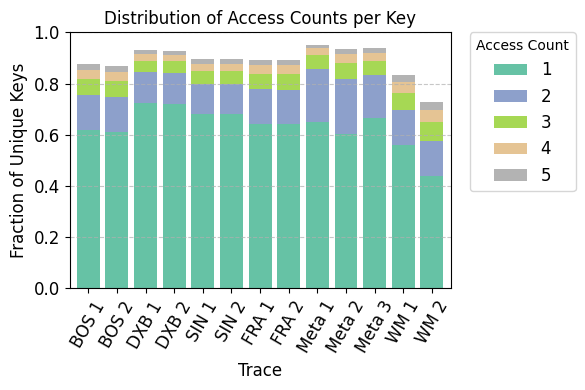

In [7]:
# Execute the query
df = q("""
WITH key_counts AS (
    SELECT 'Meta 1' AS trace, cacheKey as key, COUNT(*) AS access_count FROM '../traces/fb23/reag.parquet' GROUP BY key
    UNION ALL
    SELECT 'Meta 2' AS trace, cacheKey as key, COUNT(*) AS access_count FROM '../traces/fb23/rhna.parquet' GROUP BY key
    UNION ALL
    SELECT 'Meta 3' AS trace, cacheKey as key, COUNT(*) AS access_count FROM '../traces/fb23/rprn.parquet' GROUP BY key
    UNION ALL
    SELECT server AS trace, key, COUNT(*) AS access_count FROM '../traces/cf/**/*.parquet' GROUP BY server, key
    UNION ALL
    SELECT 'WM 1' AS trace, key, COUNT(*) AS access_count FROM '../traces/wm/t-all.parquet' GROUP BY key
    UNION ALL
    SELECT 'WM 2' AS trace, key, COUNT(*) AS access_count FROM '../traces/wm/u-all.parquet' GROUP BY key
)
SELECT
    trace,
    SUM(CASE WHEN access_count = 1 THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS a1,
    SUM(CASE WHEN access_count = 2 THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS a2,
    SUM(CASE WHEN access_count = 3 THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS a3,
    SUM(CASE WHEN access_count = 4 THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS a4,
    SUM(CASE WHEN access_count = 5 THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS a5
FROM key_counts
GROUP BY trace
ORDER BY trace
""")

# Display Table
# print(df)
df['trace_lbl'] = df['trace'].map(rename_tbl).fillna(df['trace'])

# Create Stacked Bar Chart
plt.figure(figsize=(6, 4))
df.set_index('trace_lbl').plot(kind='bar', stacked=True, figsize=(6, 4), width=0.8, colormap='Set2')
plt.title('Distribution of Access Counts per Key')
plt.ylabel('Fraction of Unique Keys')
plt.xlabel('Trace')
plt.xticks(rotation=60)
plt.legend(title='Access Count', labels=['1', '2', '3', '4', '5'], loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0)
# plt.legend(title='Access Count', labels=['1', '2', '3', '4', '5'], loc='lower left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('../paper/figs/access_count_distribution.png')
plt.show()

# TTL distributions

/tmp/ipykernel_1032486/635770794.py:71: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(-10, xmax)


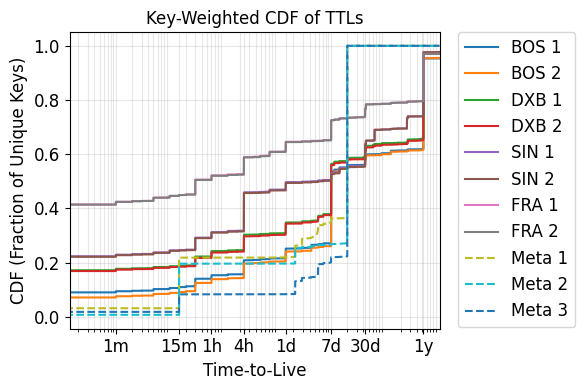

In [5]:
df_cf = q("""
SELECT 
    server AS trace, 
    FLOOR(expiry_time / 60) AS ttl_min, 
    COUNT(DISTINCT key) AS key_count 
FROM '../traces/cf/**/*.parquet' 
GROUP BY server, ttl_min
""")

df_fb_a = q('''
SELECT 
    'fb_reag' AS trace, 
    FLOOR(ttl / 60) AS ttl_min, 
    COUNT(DISTINCT cacheKey) AS key_count 
FROM '../traces/fb23/reag.parquet' 
GROUP BY ttl_min
''')

df_fb_b = q('''
SELECT 
    'fb_rhna' AS trace, 
    FLOOR(ttl / 60) AS ttl_min, 
    COUNT(DISTINCT cacheKey) AS key_count 
FROM '../traces/fb23/rhna.parquet' 
GROUP BY ttl_min
''')

df_fb_c = q('''
SELECT 
    'fb_rprn' AS trace, 
    FLOOR(ttl / 60) AS ttl_min, 
    COUNT(DISTINCT cacheKey) AS key_count 
FROM '../traces/fb23/rprn.parquet' 
GROUP BY ttl_min
''')

df = pd.concat([df_cf, df_fb_a, df_fb_b, df_fb_c])
df['trace_lbl'] = df['trace'].map(rename_tbl).fillna(df['trace'])

plt.figure(figsize=(6, 4))
xmax = 525600 * 2

for trace in sorted(df_cf['trace'].unique()):
    subset = df[df['trace'] == trace].sort_values('ttl_min')
    subset['cum_keys'] = subset['key_count'].cumsum()
    subset['cdf'] = subset['cum_keys'] / subset['key_count'].sum()
    plt.step(subset['ttl_min'], subset['cdf'], label=rename_tbl[trace], where='post')

for trace in sorted(['fb_reag', 'fb_rhna', 'fb_rprn']):
    subset = df[df['trace'] == trace].sort_values('ttl_min')
    subset['cum_keys'] = subset['key_count'].cumsum()
    subset['cdf'] = subset['cum_keys'] / subset['key_count'].sum()
    if not subset.empty and subset['cdf'].iloc[-1] >= 1.0 and subset['ttl_min'].iloc[-1] < xmax:
        subset = pd.concat([
            subset,
            pd.DataFrame({'ttl_min': [xmax], 'cdf': [1.0]})
        ], ignore_index=True)
    plt.step(subset['ttl_min'], subset['cdf'], '--', label=rename_tbl[trace], where='post')

# X-axis formatting
plt.xscale('log')
plt.xlabel('Time-to-Live')
plt.ylabel('CDF (Fraction of Unique Keys)')
plt.title('Key-Weighted CDF of TTLs')

# Standardize ticks for easier reading
# 1m, 1h, 1d, 1w, 30d
ticks = [1, 15, 60, 240, 1440, 10080, 43200, 525600]
labels = ['1m', '15m', '1h', '4h', '1d', '7d', '30d', '1y']
plt.xticks(ticks, labels)
plt.xlim(-10, xmax)

plt.grid(True, which="both", ls="-", alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.savefig('../paper/figs/ttl_cdf_by_key.png')
plt.show()